# Analyse Charge in EuXFEL switchyard

In [2]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')

import numpy as _np
import matplotlib.pyplot as _plt
import pymad8 as _m8

from pdf2image import convert_from_path
import matplotlib.patches as _patch

import XFEL_BPM
import loadXFELdata
import plotXFELdata

initializing ocelot...


### Date and save prefix

In [1]:
date = "2026_06_29"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Charge/" + date + "_EuXFEL_plot"

## Load data file

In [3]:
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file109482_20231119T155947.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file118300_20231121T155956.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file122942_20231122T155946.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file128226_20231123T155954.all.hdf5'

In [3]:
BPMData = loadXFELdata.XFELdata('XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5', 
                                getPosition=False, getCharge=True, getEnergy=False, getTime=False)

Loaded file 'matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
Loading 49 bpms, 3391 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


## Plot hist for specific BPM

In [4]:
df_bunch = BPMData.reduceDFbyBPMTrainBunchByIndex(BPMData.df_bpm, bpms="BPMA.1873.TL", trains=3, bunches=None)
df_train = BPMData.reduceDFbyBPMTrainBunchByIndex(BPMData.df_bpm, bpms="BPMA.1873.TL", trains=None, bunches=91)

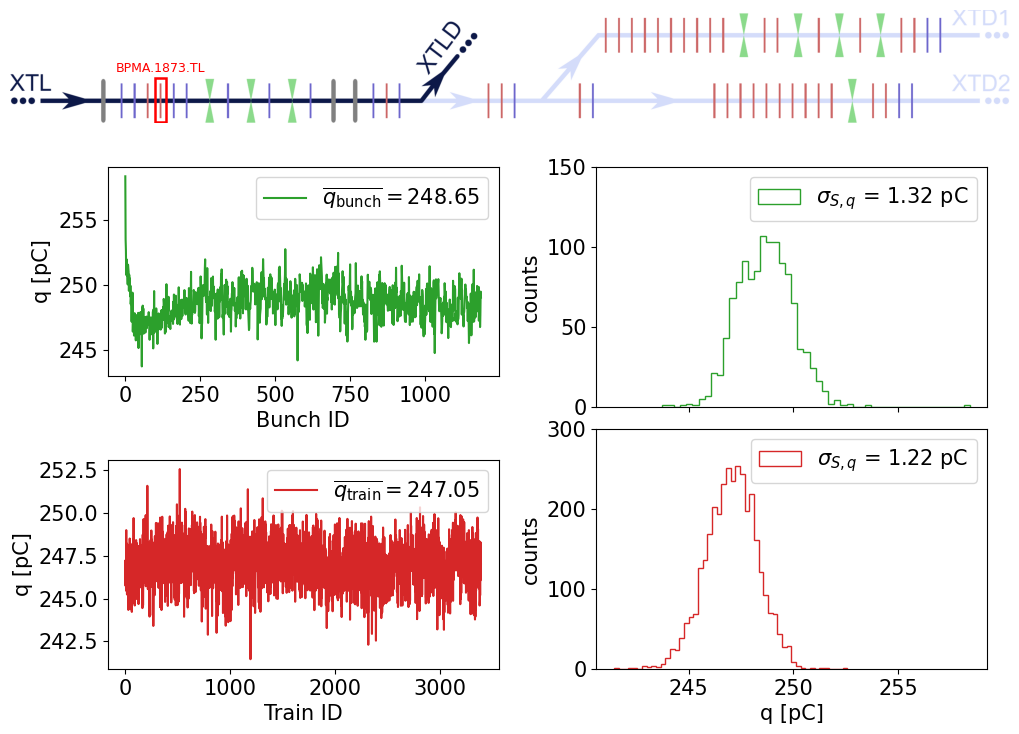

In [8]:
s_bunch = df_bunch.index.get_level_values('BunchID')
s_train = df_train.index.get_level_values('TrainID')
s_train -= s_train[0]
Q_bunch = df_bunch['Charge'] * 1e12
Q_train = df_train['Charge'] * 1e12

img = convert_from_path("../../../Drawings/XS1_diag_XTLD.pdf", dpi=300)[0]
fig = _plt.figure(figsize=[10, 8])
# gs = fig.add_gridspec(1, 2)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 3])
ax_pdf = fig.add_axes([0, 0.75, 1, 0.2])
ax_pdf.imshow(img)
ax_pdf.axis('off')
arrow = _patch.Rectangle((394, 185), 30, 120, lw=1.8, fill=False, color='r')
ax_pdf.add_patch(arrow)
ax_pdf.text(394+30/2, 185-9, "BPMA.1873.TL", color='r', ha='center', va='bottom', fontsize=9)
left_gs = gs[1, 0].subgridspec(2, 1, hspace=0.4)
right_gs = gs[1, 1].subgridspec(2, 1)
ax_left1 = fig.add_subplot(left_gs[0, 0])
ax_left2 = fig.add_subplot(left_gs[1, 0])
ax_right1 = fig.add_subplot(right_gs[0, 0])
ax_right2 = fig.add_subplot(right_gs[1, 0], sharex=ax_right1)
ax_right1.tick_params(labelbottom=False)
ax_left1.plot(s_bunch, Q_bunch, color='C2', label=r"$\overline{{q_{{\rm bunch}}}}=${:.2f}".format(_np.mean(Q_bunch)))
ax_left2.plot(s_train, Q_train, color='C3', label=r"$\overline{{q_{{\rm train}}}}=${:.2f}".format(_np.mean(Q_train)))
ax_right1.hist(Q_bunch, bins=50, histtype='step', color='C2', label=r"$\sigma_{{S,q}}$ = {:.2f} $\rm pC$".format(_np.std(Q_bunch)))
ax_right2.hist(Q_train, bins=50, histtype='step', color='C3', label=r"$\sigma_{{S,q}}$ = {:.2f} $\rm pC$".format(_np.std(Q_train)))
ax_left1.legend()
ax_left2.legend()
ax_right1.legend()
ax_right2.legend()
ax_right1.set_ylim([0, 150])
ax_right2.set_ylim([0, 300])
ax_right1.set_ylabel('counts')
ax_right2.set_ylabel('counts')
ax_right2.set_xlabel('q [pC]')
ax_left1.set_ylabel('q [pC]')
ax_left2.set_ylabel('q [pC]')
ax_left1.set_xlabel('Bunch ID')
ax_left2.set_xlabel('Train ID')
_plt.tight_layout()
_plt.savefig("{}_BPM_XTL_charge.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

## BPM signal along the line

In [7]:
df_reduced = BPMData.reduceDFbyBPMTrainBunchByIndex(BPMData.df_bpm, bpms=None, trains=None, bunches=91)

Mad8.readTwissFile > nrec=8411


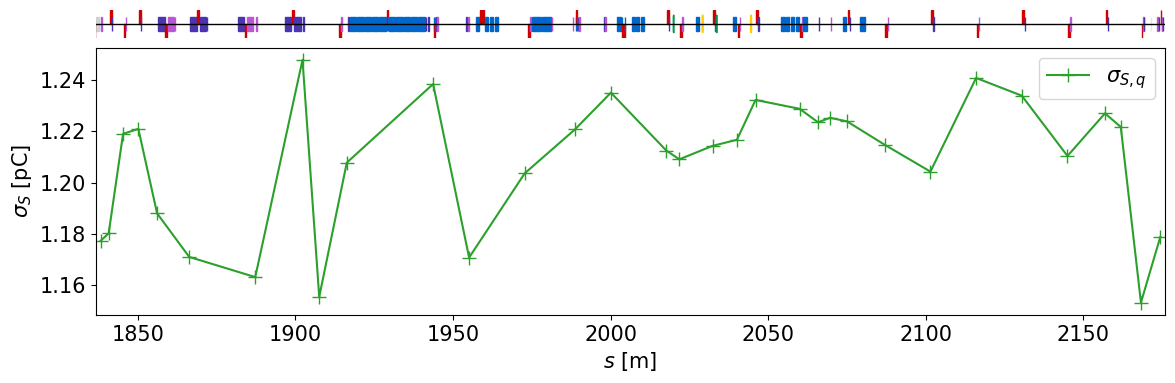

In [17]:
bpm_names = df_reduced.index.get_level_values('BPM').unique()
sq = []
for i, bpm_name in enumerate(bpm_names):
    df_bpm = df_reduced.xs(bpm_name, level='BPM')
    sq.append(_np.std(df_bpm.Charge))
s = BPMData.getS(df_reduced)
_plt.figure(figsize=[12, 4])
_plt.xlabel(r"$s$ [m]")
_plt.plot(s, _np.array(sq) * 1e12, '+-', color='C2', label=r"$\sigma_{S, q}$", markersize=10, markeredgewidth=1)
_plt.ylabel(r"$\sigma_S$ [pC]")
_plt.legend()
plotXFELdata.addLattice('../01_mad8/XFEL_Lattice_9/TWISS_T5D', s)
_plt.savefig("{}_BPMs_XTD1_charge_signal.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


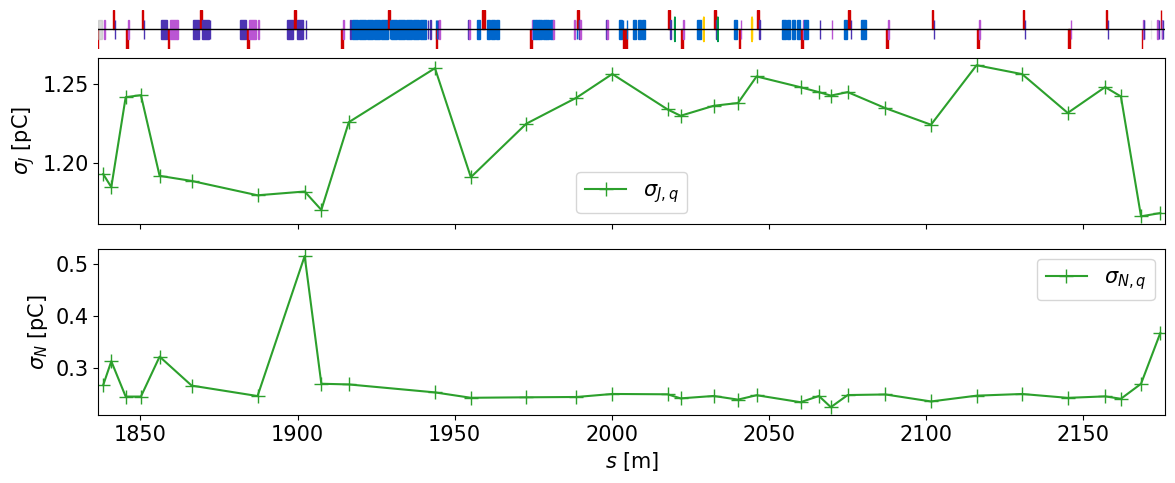

In [8]:
plotXFELdata.plotJitterNoiseCharge(BPMData, df_reduced, lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_charge_jitter_noise.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [16]:
average = loadXFELdata.XFELdata('XFEL_data/BPM_data/matched_linac_main_run2148_file128226_20231123T155954.all.hdf5', 
                                getPosition=False, getCharge=True)

Loaded file 'matched_linac_main_run2148_file128226_20231123T155954.all.hdf5'
Loading 49 bpms, 3180 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


In [20]:
df_red = average.reduceDFbyBPMTrainBunchByIndex(average.df_bpm, bpms=['BPMI.1910.TL', 'BPMI.1925.TL', 'BPMI.1930.TL', 'BPMI.1939.TL'])
bunchIDs = []
jq_mean = []
for bunchID in average.bunchIDs_XTLD[::10]:
    print("{}/{} bunches".format(bunchID, len(average.bunchIDs_XTLD)), end='\r')
    df = average.reduceDFbyBPMTrainBunchByIndex(df_red, bunches=bunchID)
    jq, nq = average.calcJitterAndNoise(df, 'Charge')
    jq_mean.append(jq.mean())
    bunchIDs.append(bunchID)
    print("{}/{} bunches".format(len(average.bunchIDs_XTLD), len(average.bunchIDs_XTLD)), end='\r')

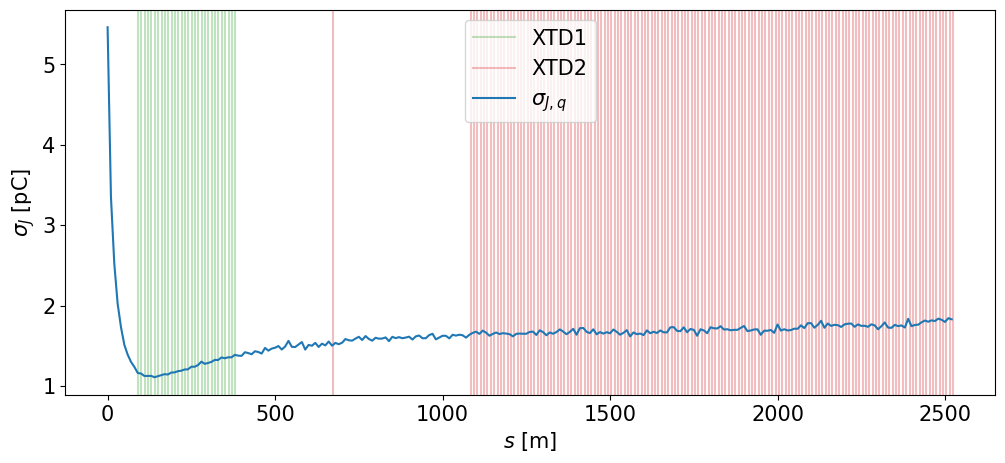

In [38]:
_plt.figure(figsize=[12, 5])
_plt.xlabel(r"$s$ [m]")
labelT1 = 'XTD1'
labelT2 = 'XTD2'
for bunchT1 in average.bunchIDs_XTD1[::10]:
    _plt.axvline(bunchT1, color='C2', alpha=0.3, label=labelT1)
    labelT1 = None
for bunchT2 in average.bunchIDs_XTD2[::5]:
    _plt.axvline(bunchT2, color='C3', alpha=0.3, label=labelT2)
    labelT2 = None
_plt.plot(bunchIDs, _np.array(jq_mean)*1e12, color='C0', label=r"$\sigma_{J,q}$")
_plt.ylabel(r"$\sigma_{J}$ [pC]")
_plt.legend(loc=9)
_plt.savefig("{}_BPMs_charge_bunch_jitter.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')